<a href="https://colab.research.google.com/github/iprachuk/Restaurant-Analysis/blob/main/Restaurant_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount("/content/drive")
%cd /content/drive/MyDrive/Mate/Collaborative/Files

Mounted at /content/drive
/content/drive/MyDrive/Mate/Collaborative/Files


#**1. Вилучення даних та об'єднання**

In [ ]:
#Connecting to a database on Google Drive
conn = sqlite3.connect('/content/drive/MyDrive/Mate/Collaborative/Files/db.sqlite3')
cur = conn.cursor()
#read name of tables
table = cur.execute("SELECT name FROM sqlite_master WHERE type = 'table' and name NOT LIKE 'sqlite_%'")
table.fetchall()

#read table in separated variable
orders = pd.read_sql_query("SELECT * FROM restaurant_order", conn)
products = pd.read_sql_query("SELECT * FROM restaurant_product", conn)
orderitems = pd.read_sql_query("SELECT * FROM restaurant_orderitem", conn)

#Combining 3 tables into 1
merged_df = orderitems.merge(orders, left_on = 'order_id', right_on = 'id', how = 'outer') \
                      .merge(products, left_on = 'product_id', right_on = 'id', how = 'outer')

#create csv-file
merged_df.to_csv('/content/drive/MyDrive/Mate/Collaborative/Files/restaurant_data.csv', index = False)

#read csv with pandas
df = pd.read_csv('/content/drive/MyDrive/Mate/Collaborative/Files/restaurant_data.csv')

#checking the number of rows
print(df.shape)
orderitems.head()

(74818, 9)


,id,quantity,order_id,product_id
0,1,2,1,6
1,2,1,1,240
2,3,1,1,19
3,4,1,1,36
4,5,1,1,111


In [ ]:
#overview by dataset
df.info()

#search for duplicate values
df.duplicated()

#data types
print(df.dtypes)
#check the number of empty values and their percent
print(df.isna().sum())
print(df.isna().sum() / df.shape[0] * 100)

#change type for column datetime
df['datetime'] = df['datetime'].astype("datetime64[ns]")

#I deleted one by one fields with other tables that I used for combined
df = df.drop(columns = ["id_y", "id"])
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74818 entries, 0 to 74817
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_x        74818 non-null  int64  
 1   quantity    74818 non-null  int64  
 2   order_id    74818 non-null  int64  
 3   product_id  74818 non-null  int64  
 4   id_y        74818 non-null  int64  
 5   datetime    74818 non-null  object 
 6   id          74818 non-null  int64  
 7   price       74818 non-null  float64
 8   name        74818 non-null  object 
dtypes: float64(1), int64(6), object(2)
memory usage: 5.1+ MB
id_x            int64
quantity        int64
order_id        int64
product_id      int64
id_y            int64
datetime       object
id              int64
price         float64
name           object
dtype: object
id_x          0
quantity      0
order_id      0
product_id    0
id_y          0
datetime      0
id            0
price         0
name          0
dtype: int64
id_x      

,id_x,quantity,order_id,product_id,datetime,price,name
0,44,2,9,1,2019-08-03 19:28:00,0.5,Mint Sauce
1,60,2,11,1,2019-08-03 19:25:00,0.5,Mint Sauce
2,80,1,14,1,2019-08-03 18:36:00,0.5,Mint Sauce
3,106,1,19,1,2019-08-03 18:00:00,0.5,Mint Sauce
4,113,1,20,1,2019-08-03 17:58:00,0.5,Mint Sauce


#**2. Top-10 the most popular products by count of orders**

On the chart we have 3 products which have more than 50% (55.3%) from all units which sold. Plain Papadum Plain papadums represent 1/4 of total sales:

**Plain Papadum           10648**

**Pilau Rice            6367**

**Plain Naan            4983**

                     name  sum_of_product
188         Plain Papadum           10648
186            Pilau Rice            6367
187            Plain Naan            4983
81            Garlic Naan            3318
189            Plain Rice            2964
165          Onion Bhajee            2749
144         Mango Chutney            2504
52   Chicken Tikka Masala            2473
26                Chapati            1935
153            Mint Sauce            1840


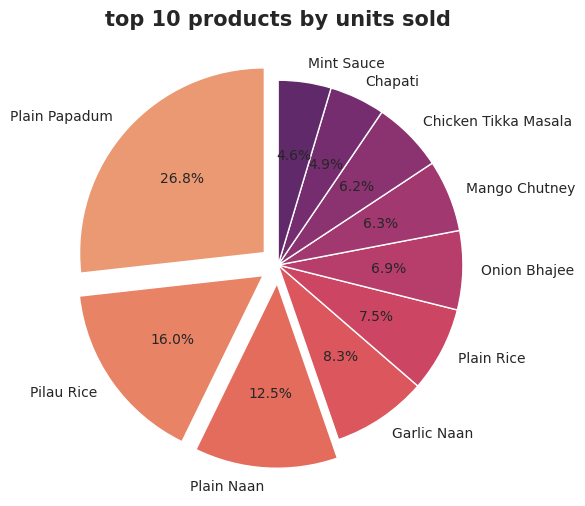

In [ ]:
#counting the number of items sold
number_of_items_sold = df.groupby("name").agg(sum_of_product = ("quantity", "sum")).reset_index().sort_values(by="sum_of_product", ascending = False)

#A ranking of the 10 most popular products by quantity has been compiled
top_10_products_by_units = number_of_items_sold.head(10)

print(top_10_products_by_units)
#visualization of pie chart
sns.set_style("whitegrid")
explode = [0.1, 0.1, 0.1, 0, 0, 0, 0, 0, 0, 0]
plt.figure(figsize=(10,6))
plt.pie(top_10_products_by_units['sum_of_product'], labels = top_10_products_by_units['name'], autopct='%1.1f%%',explode=explode, startangle=90, colors = sns.color_palette('flare', 10))
plt.title("top 10 products by units sold", style = "normal", weight = "bold", fontsize=15)
plt.show()

#**3.Top 10 Most Profitable Products by Unit Price**
In comparison sales by count of units we have some changes in top-3 positions.

The product that previously ranked 8th in sales of units now ranks first, which indicates a high price point and, consequently, higher profits; as for second and third place, they remained in their previous positions but lost 2% compared to the previous results.

**1. Chicken Tikka Masala - 22133.35$**

**2. Pilau Rice - 18782.65 $**

**3. Plain Naan - 12955.80 $**

                     name  total_revenue
52   Chicken Tikka Masala       22133.35
186            Pilau Rice       18782.65
187            Plain Naan       12955.80
97                  Korma       12261.50
16            Bombay Aloo       10894.45
165          Onion Bhajee       10858.55
20         Butter Chicken       10626.60
81            Garlic Naan        9788.10
98        Korma - Chicken        9764.45
189            Plain Rice        8743.80


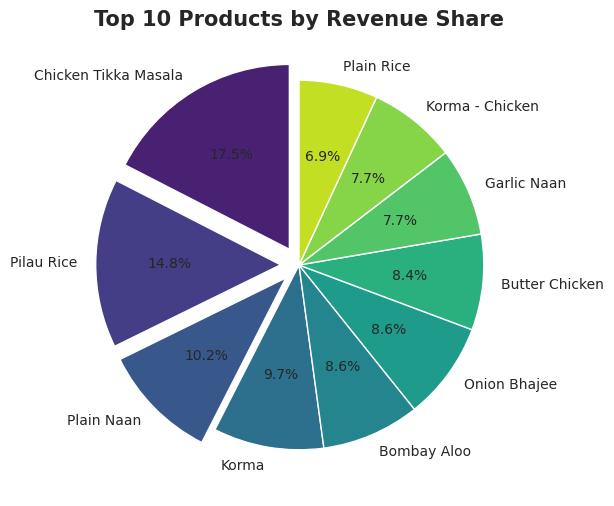

In [ ]:
#Total for all orders, broken down by rows
df['revenue'] = df['quantity'] * df['price']

#sum by products
total_revenue_by_products = df.groupby('name').agg(total_revenue=('revenue', 'sum')).reset_index().sort_values(by='total_revenue', ascending=False)

#top10 products by revenue
top_10_products_by_revenue = total_revenue_by_products.head(10)
print(top_10_products_by_revenue)

#visualization
explode = [0.1, 0.1, 0.1, 0, 0, 0, 0, 0, 0, 0]
plt.figure(figsize=(10, 6))
plt.pie(top_10_products_by_revenue['total_revenue'], labels=top_10_products_by_revenue['name'], autopct='%1.1f%%',explode = explode, startangle=90, colors=sns.color_palette('viridis', 10))
plt.title('Top 10 Products by Revenue Share', weight='bold', fontsize=15)
plt.show()

#**4. Analysis of revenue by hours.**
Generally, all restaurants see the highest foot traffic in the evening, as shown in the bar chart.

Restaurant shows peak traffic between 17 and 21 hours, average revenue in this time - ***90959.0$.***






In [ ]:
#create new column with hours from order time
df['hour of order'] = df['datetime'].dt.hour

#aggregation by hour
total_revenue_by_hours = df.groupby('hour of order').agg(revenue_by_hours = ('revenue', 'sum'))

#average value of revenue in the peak time
average_top3_hours = total_revenue_by_hours.sort_values(by = "revenue_by_hours", ascending = False).head(4)
print(average_top3_hours.values.mean())

#visualization
plt.figure(figsize=(13,6))
sns.barplot(x = total_revenue_by_hours.index, hue = total_revenue_by_hours.index, y = total_revenue_by_hours["revenue_by_hours"], palette = "rocket_r",legend = False)
plt.title('Total Revenue by hours of day', weight='bold', fontsize=15)
plt.xlabel('Hours of day')
plt.ylabel('Total Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

NameError: name 'df' is not defined

#**5. Analysis of revenue by day of week**

We've seen a stable trend throughout the week, with earnings not exceeding 45k, but starting Friday, we've seen a sharp spike in revenue to 100k, rising to over 100k on Saturday, and then settling down to a more moderate 60k on Sunday.

**We've noticed an upward trend in customer traffic toward the end of the week.**

           revenue_by_day_of_week
Monday                   40008.30
Tuesday                  38145.65
Wednesday                41246.20
Thursday                 46021.55
Friday                  100339.15
Saturday                112191.65
Sunday                   67105.95


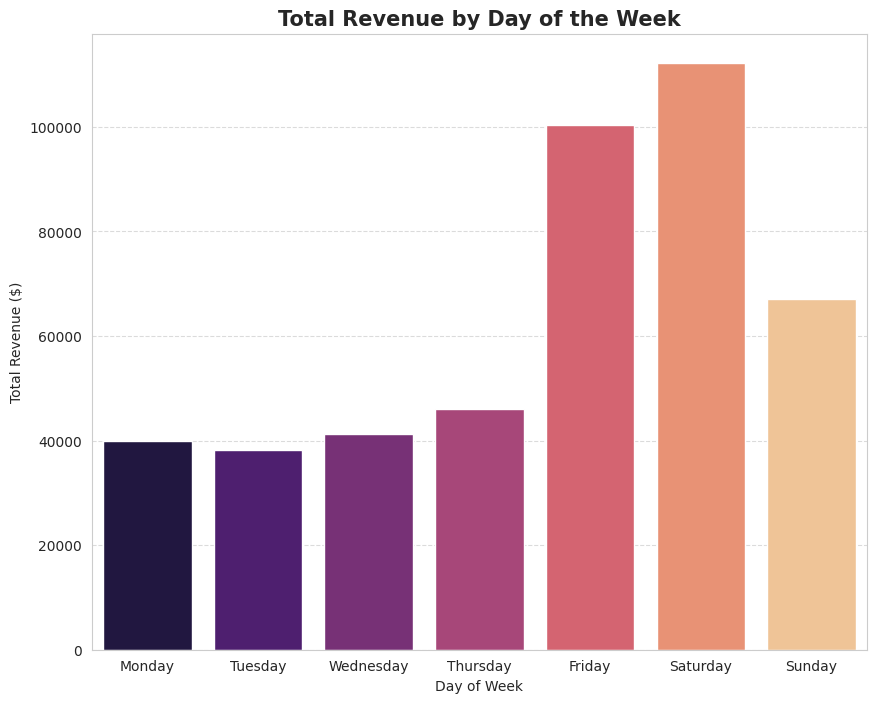

In [ ]:
#create now columns which have numbers of day of week
df["day of week"] = df['datetime'].dt.day_of_week

#aggregation by day of week
total_revenue_by_days = df.groupby('day of week').agg(revenue_by_day_of_week = ('revenue', 'sum'))

#true sorting by day of week
total_revenue_by_days.index = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
print(total_revenue_by_days)

#visualization
plt.figure(figsize=(10, 8))
sns.barplot(x=total_revenue_by_days.index, y=total_revenue_by_days['revenue_by_day_of_week'], hue = total_revenue_by_days.index, palette='magma', legend =False)
plt.title('Total Revenue by Day of the Week', weight='bold', fontsize=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#**Overall result**

*So, we can see that revenue doesn’t always depend solely on the number of items sold.*

*The price per item also plays a significant role. In the sales pie chart, our products simply switched places—from 1st to 8th.*

*As for our restaurant, peak traffic occurs on weekends and in the afternoon.*